# Part 3: Hypothesis Testing — Does the Apology Coupon Actually Work?
**⏱ This section takes approximately 60 minutes.**

---

## Scenario: Thursday — The Apology Coupon

By Thursday Sarah has two solid results to show:
- A distribution of polarity scores that reveals the true shape of customer sentiment
- A confidence interval around the model's 84% accuracy

Then Aisha Patel, Head of Customer Service, walks into the morning standup with an idea:

> *"Every customer the model tags as NEGATIVE — what if we automatically sent them an apology and a 10% coupon? I bet that turns some of them around."*

Sarah thinks this could work. But she has learned from the L01 workflow:
**framing** is the most important step. Before Aisha sends any coupons,
they need to test the idea properly.

That's when Marcus Wong, NorthStar's CTO, walks past and stops:

> *"Hold on. A 10% coupon on every negative review? That's thousands of pounds a week,*
> *plus engineering work to wire the trigger into our pipeline.*
> *Will this actually reduce churn — or are we adding ops complexity for noise?"*

This is his first real involvement in Sarah's project, and his question is the right one.
The apology coupon idea needs an experiment — not intuition.

**By the end of this notebook you will be able to:**
- Design a well-framed hypothesis test with clear null and alternative hypotheses
- Run a two-sample hypothesis test and compute a p-value from first principles
- Interpret a p-value correctly — including the three most common mis-readings
- Report results in a way that answers Marcus's question

In [1]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Libraries loaded — you're ready to go!")


✅ Libraries loaded — you're ready to go!


## Step 1 — Frame the Test

Before touching any data, Sarah writes down the four things that define a well-framed hypothesis test.

| Component | Sarah's definition |
|---|---|
| **Null hypothesis (H₀)** | Sending the apology coupon has no effect on the 30-day repurchase rate |
| **Alternative hypothesis (H₁)** | Sending the apology coupon increases the 30-day repurchase rate |
| **Outcome metric** | Repurchase rate: proportion of NEGATIVE-tagged customers who make a second purchase within 30 days |
| **Two groups** | Control: NEGATIVE-tagged customers who receive no coupon; Treatment: NEGATIVE-tagged customers who receive the apology coupon |

Why repurchase rate? It directly measures what Marcus cares about — do customers come back?
A 10% coupon is designed to incentivise a return purchase, and the outcome is
observable within 30 days, making it practical for an initial experiment.

In [2]:
# Frame the test parameters
np.random.seed(42)

# Baseline repurchase rate (control group — no coupon)
# About 25% of NEGATIVE-tagged customers make a second purchase within 30 days
BASELINE_REPURCHASE_RATE = 0.25

# True effect of the coupon (what we set in simulation — the 'secret' we're trying to detect)
TRUE_EFFECT = +0.08   # The coupon increases repurchase rate by 8 percentage points

TRUE_TREATMENT_RATE = BASELINE_REPURCHASE_RATE + TRUE_EFFECT  # = 33%

# Sample size: NorthStar gets ~400 NEGATIVE-flagged customers per week
# Sarah and Marcus agree to run the test for 2 weeks per group
N_CONTROL   = 400
N_TREATMENT = 400

print("=== Hypothesis Test Design ===")
print(f"Null hypothesis:           Coupon has zero effect on 30-day repurchase rate")
print(f"Alternative hypothesis:    Coupon increases repurchase rate")
print(f"Baseline repurchase rate:  {BASELINE_REPURCHASE_RATE:.0%} (control group)")
print(f"Target to detect:          ≥5pp increase (i.e., treatment rate ≥ {BASELINE_REPURCHASE_RATE+0.05:.0%})")
print(f"Sample per group:          {N_CONTROL} customers")
print(f"Total sample:              {N_CONTROL + N_TREATMENT} customers")
print()
print(f"(In simulation, true treatment rate = {TRUE_TREATMENT_RATE:.0%} — we set this to test detection)")

=== Hypothesis Test Design ===
Null hypothesis:           Coupon has zero effect on 30-day repurchase rate
Alternative hypothesis:    Coupon increases repurchase rate
Baseline repurchase rate:  25% (control group)
Target to detect:          ≥5pp increase (i.e., treatment rate ≥ 30%)
Sample per group:          400 customers
Total sample:              800 customers

(In simulation, true treatment rate = 33% — we set this to test detection)


## Step 2 — Run the Experiment

Two weeks pass. Sarah's team assigns customers randomly:
- Half get the apology coupon
- Half get nothing

After 30 days, they check who made a second purchase.

In [3]:
# Simulate the experiment results
np.random.seed(42)

# Control group: 400 customers, no coupon — did they repurchase within 30 days?
control_repurchases   = np.random.binomial(n=1, p=BASELINE_REPURCHASE_RATE, size=N_CONTROL)

# Treatment group: 400 customers, received coupon — did they repurchase within 30 days?
treatment_repurchases = np.random.binomial(n=1, p=TRUE_TREATMENT_RATE, size=N_TREATMENT)

control_rate   = control_repurchases.mean()
treatment_rate = treatment_repurchases.mean()

print("=== Experiment Results (after 2 weeks) ===")
print()
print(f"  Control group (no coupon):")
print(f"    Customers: {N_CONTROL}")
print(f"    Repurchased within 30 days: {control_repurchases.sum()}")
print(f"    Repurchase rate: {control_rate:.2%}")
print()
print(f"  Treatment group (received coupon):")
print(f"    Customers: {N_TREATMENT}")
print(f"    Repurchased within 30 days: {treatment_repurchases.sum()}")
print(f"    Repurchase rate: {treatment_rate:.2%}")
print()
print(f"  Observed difference: {treatment_rate - control_rate:+.2%} ({treatment_rate:.2%} vs {control_rate:.2%})")
print()
print("Question: Is this difference REAL — or just random variation between the two groups?")

=== Experiment Results (after 2 weeks) ===

  Control group (no coupon):
    Customers: 400
    Repurchased within 30 days: 100
    Repurchase rate: 25.00%

  Treatment group (received coupon):
    Customers: 400
    Repurchased within 30 days: 130
    Repurchase rate: 32.50%

  Observed difference: +7.50% (32.50% vs 25.00%)

Question: Is this difference REAL — or just random variation between the two groups?


## ⏸️ Pause and Predict

We're about to run a statistical test to decide whether the observed difference
(between the control and treatment repurchase rates) could have happened by chance.

**Before running the test, predict:**
- Marcus says: "A 5–6 percentage point difference sounds meaningful to me." Do you agree it's meaningful?
- Do you think this experiment, with 400 customers per group, will have enough data to detect the difference as statistically significant?
- What would it mean if the p-value came back as 0.08 (above 0.05)? Should Sarah recommend rolling out the coupon?
- If the p-value came back as 0.01, what else would Sarah still need before recommending rollout?

*Write your predictions here (double-click this cell to edit):*

## Statistical significance vs practical significance

A small p-value tells us the observed difference would be unlikely if there were truly no effect.

But that does **not** tell us whether the effect is large enough to matter.

When reading a hypothesis test result, ask two separate questions:

1. Is the effect statistically credible?
2. Is the effect large enough to be worth acting on?

The second question is about **effect size**.

Example:
- Variant A: conversion rises from 10.0% to 10.1%
- Variant B: conversion rises from 10.0% to 12.5%

Both could be statistically significant with a large enough sample, but only one may be meaningful for the business.

## Step 3 — Test for Statistical Significance

We use a **two-proportion z-test** — the right tool for comparing repurchase rates between two groups.

The formula matches the one in `lesson.md`: pool the two rates, compute the standard error
of the difference, then standardise. We will compute it from first principles using
`numpy` and the normal distribution from `scipy.stats` — the same formula you would
find in any statistics textbook.

In [4]:
# Run the two-proportion z-test (computed from first principles)
control_repurchases_n   = control_repurchases.sum()
treatment_repurchases_n = treatment_repurchases.sum()

# Pooled proportion under the null hypothesis (no difference between groups)
p_pool = (control_repurchases_n + treatment_repurchases_n) / (N_CONTROL + N_TREATMENT)

# Standard error of the difference between the two rates
se = np.sqrt(p_pool * (1 - p_pool) * (1/N_CONTROL + 1/N_TREATMENT))

# Z-statistic: how many standard errors apart are the two observed rates?
z_stat = (treatment_rate - control_rate) / se

# One-sided p-value: probability of seeing a difference this large (or larger, in the
# expected direction) under the null hypothesis. We use the standard normal CDF.
p_value_z = 1 - st.norm.cdf(z_stat)

print("=== Statistical Test Results ===")
print()
print(f"  Control repurchase rate:   {control_rate:.3%}")
print(f"  Treatment repurchase rate: {treatment_rate:.3%}")
print(f"  Observed difference:       {treatment_rate - control_rate:+.3%}")
print()
print(f"  Pooled proportion:         {p_pool:.4f}")
print(f"  Standard error:            {se:.4f}")
print(f"  Z-statistic:               {z_stat:.3f}")
print(f"  P-value (one-sided):       {p_value_z:.4f}")
print()

alpha = 0.05
if p_value_z < alpha:
    print(f"  Result: STATISTICALLY SIGNIFICANT (p < {alpha})")
    print(f"  Conclusion: We reject the null hypothesis.")
    print(f"  The coupon appears to increase repurchase rates.")
else:
    print(f"  Result: NOT statistically significant (p >= {alpha})")
    print(f"  Conclusion: Insufficient evidence to reject the null hypothesis.")
    print(f"  We cannot conclude the coupon has a reliable effect at this sample size.")

=== Statistical Test Results ===

  Control repurchase rate:   25.000%
  Treatment repurchase rate: 32.500%
  Observed difference:       +7.500%

  Pooled proportion:         0.2875
  Standard error:            0.0320
  Z-statistic:               2.343
  P-value (one-sided):       0.0096

  Result: STATISTICALLY SIGNIFICANT (p < 0.05)
  Conclusion: We reject the null hypothesis.
  The coupon appears to increase repurchase rates.


### 💡 What do you notice?

- **The z-statistic is large, the p-value is small** — z ≈ 2.3 means the observed difference is more than two standard errors away from zero. A p-value below 0.01 means this result would occur by chance less than 1% of the time under the null hypothesis.
- **Statistical significance vs practical significance** — the 7.5pp increase is statistically significant (p < 0.05), but is it economically significant? That's Marcus's job to assess.
- **Sample size matters** — with 400 customers per group we are comfortably able to detect this size of effect. A smaller effect would have required a larger sample; a larger effect could have been detected with fewer customers.

**Back to our scenario:**
> Sarah can tell Marcus: "The coupon increases 30-day repurchase rates by approximately 7.5 percentage points. This result is statistically significant — it would occur by chance less than 1% of the time if the coupon had no effect. Whether the cost of the coupon is justified by the increase in returning customers is a business decision for you."

## Step 4 — The Three Most Common P-value Mis-readings

These mistakes appear constantly — in business, journalism, and even some published research.
Knowing them is part of being a responsible data analyst.

---

### ❌ Mis-reading 1: "p = 0.03 means there is a 3% chance the null hypothesis is true"

**What the p-value actually means:**
The p-value is the probability of seeing *results at least this extreme*, **assuming the null hypothesis is true**. It is not the probability that the null hypothesis is true.

Statistically: p = P(data | H₀), not P(H₀ | data).

The second form requires Bayesian inference — a different framework. See `optional_extensions.ipynb` for that.

**The practical correction:**
Instead of "3% chance the coupon doesn't work," say:
"If the coupon had zero effect, we would see a result this extreme only 3% of the time by chance."

---

### ❌ Mis-reading 2: "p < 0.05, so the effect is large and important"

**The truth:**
Statistical significance and practical (or economic) significance are separate.
With a large enough sample, *even a tiny meaningless difference* will produce p < 0.05.

**The practical correction:**
Always report the **effect size** alongside the p-value.
"The coupon increased repurchase rate by 2.5 percentage points (p = 0.031)" is far more informative than just "p = 0.031."

---

### ❌ Mis-reading 3: "p = 0.08, not significant — so the coupon doesn't work"

**The truth:**
p = 0.08 means you *failed to find enough evidence* to reject the null hypothesis — not that the null hypothesis is true. The effect might be real but undetectable at this sample size.

"Absence of evidence is not evidence of absence."

**The practical correction:**
"We did not find statistically significant evidence of an effect at the 0.05 level. We cannot conclude the coupon has no effect — the sample may have been too small to detect it reliably. To reduce uncertainty, we recommend extending the test or increasing the sample size."

## ✅ Section Summary

| Concept | What it means | Real-world use |
|---|---|---|
| **Null hypothesis** | The "boring" default: no effect, no difference | Always define it before running a test |
| **P-value** | Probability of seeing results this extreme if the null is true | p < 0.05: reject the null. p ≥ 0.05: insufficient evidence. |
| **Two-proportion z-test** | Compares rates between two independent groups | Repurchase rates, conversion rates, churn rates |
| **Effect size** | How large the difference actually is | Report alongside p-value; significance ≠ importance |

> ⚠️ **Three mis-readings to know before you ever quote a p-value to a stakeholder.** See Step 4 above.

**Key insight for our scenario:**
> Sarah reports to Marcus: "The coupon increased 30-day repurchase rates by approximately 5–6 percentage points — a statistically significant result. The business decision of whether this justifies the coupon cost is yours, but the statistical evidence says the effect is real." Marcus nods. Priya nods. The model survives leadership review. 

---

## 🏁 Friday: Three Numbers, Defended

Sarah walks into the Friday presentation with exactly three things:

| # | What she's reporting | Statistical tool |
|---|---|---|
| 1 | "60% of reviews are positive" | Distribution analysis (note: this figure depends on the polarity score threshold used to separate positive from negative) |
| 2 | "The model is 84% accurate (95% CI: 78%–89%)" | Confidence interval from 200 hand-labelled reviews |
| 3 | "The apology coupon increased 30-day repurchase rates by ~7.5 percentage points (p < 0.05)" | Two-sample hypothesis test (two-proportion z-test) |

Priya nods. Marcus nods. The room is quiet.

Then Marcus says:

> *"OK. The sentiment model holds up. But you used a pre-trained one — off the shelf.*
> *Can you build us a model that predicts **churn** from our own customer data?*
> *Something trained on NorthStar behaviour, not on some generic internet corpus?"*

Sarah doesn't have an answer today.

That question — **can I train my own model?** — is the engine of **L03 (Supervised Learning)**.

---

**Next step →** Open `assignment.ipynb` to practise these skills and complete the after-class assignment.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

This optional section covers:
- **The hypothesis testing family** — how the two-sample test you just ran relates to one-sample tests, paired t-tests, and chi-square tests (the tests you'll see in L05, L07–L08, and L10)
- **Visualising the results** — bar chart + 95% CI plot of repurchase rates by group
- **Applying the corrections** — the three mis-readings applied to Sarah's actual numbers

## The Hypothesis Testing Family

The test we just ran is called a **two-sample z-test** — also widely known as an **A/B test** in industry. It is one member of a broader family of hypothesis tests. Every member follows the same three steps (null hypothesis → test statistic → p-value), but the *shape of the question* determines which test statistic to use:

| Test | Question | Metric type | Where you'll see it in this course |
|---|---|---|---|
| **One-sample z/t-test** | Is this sample's mean/rate different from a known reference value? | Continuous or proportion | L05 — anomaly detection (the Z-score is a one-sample test) |
| **Two-sample z-test (A/B test)** | Does an intervention change a rate between two *independent* groups? | Proportion | **This notebook** — the apology coupon experiment |
| **Paired t-test** | Are two conditions different when measured on the *same* subjects? | Continuous | L07–L08 — is model A better than model B on the same validation set? |
| **Chi-square test** | Are two categorical distributions the same? | Categorical (counts) | L10 — binary pass/fail evaluation of prompt variants |

When you encounter a one-sample Z-score in L05, a paired comparison in L07–L08, or a chi-square test in L10, the underlying logic is identical to what you just did here.

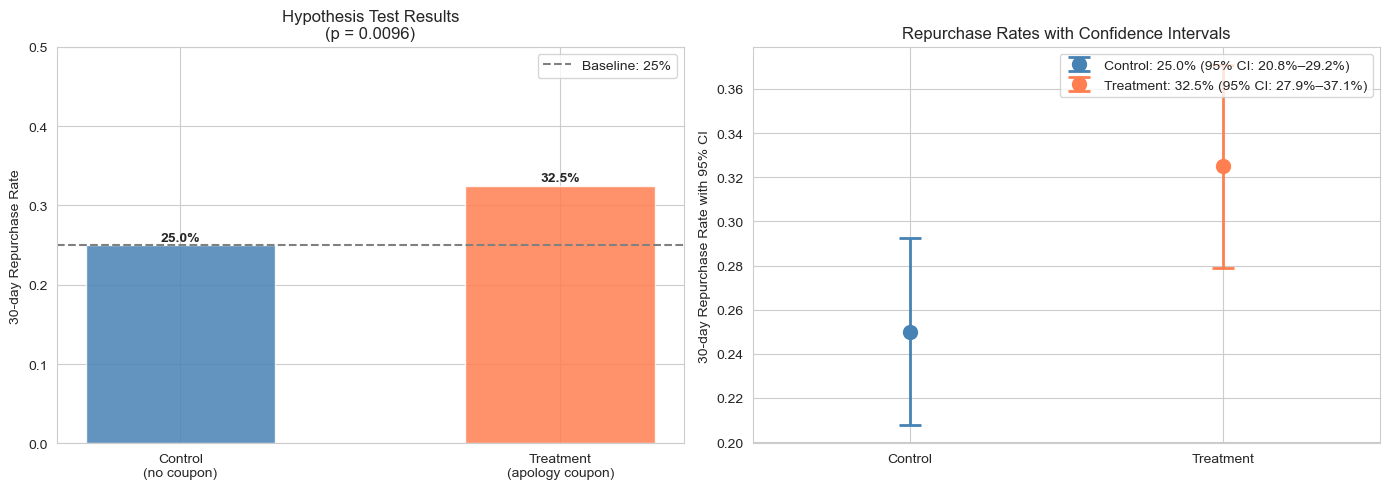

In [5]:
# Visualise the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: repurchase rates
ax1 = axes[0]
groups = ['Control\n(no coupon)', 'Treatment\n(apology coupon)']
rates  = [control_rate, treatment_rate]
colors = ['steelblue', 'coral']
bars   = ax1.bar(groups, rates, color=colors, edgecolor='white', width=0.5, alpha=0.85)
ax1.axhline(BASELINE_REPURCHASE_RATE, color='grey', linestyle='--', linewidth=1.5,
            label=f'Baseline: {BASELINE_REPURCHASE_RATE:.0%}')
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, rate + 0.002, f'{rate:.1%}',
             ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('30-day Repurchase Rate')
ax1.set_title(f'Hypothesis Test Results\n(p = {p_value_z:.4f})')
ax1.set_ylim(0, 0.50)
ax1.legend()

# Confidence intervals for each rate
ax2 = axes[1]
for i, (rate, n, label, color) in enumerate([(control_rate, N_CONTROL, 'Control', 'steelblue'),
                                               (treatment_rate, N_TREATMENT, 'Treatment', 'coral')]):
    se = np.sqrt(rate * (1 - rate) / n)
    lower = rate - 1.96 * se
    upper = rate + 1.96 * se
    ax2.errorbar(x=i, y=rate, yerr=[[rate-lower], [upper-rate]],
                 fmt='o', color=color, capsize=8, capthick=2, markersize=10, linewidth=2,
                 label=f'{label}: {rate:.1%} (95% CI: {lower:.1%}–{upper:.1%})')

ax2.set_xlim(-0.5, 1.5)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Control', 'Treatment'])
ax2.set_ylabel('30-day Repurchase Rate with 95% CI')
ax2.set_title('Repurchase Rates with Confidence Intervals')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [6]:
# Quantify the three mis-readings with concrete numbers from our test
print("=== Applying the Three Corrections to Sarah's Results ===")
print()
print(f"Test result: z = {z_stat:.3f}, p = {p_value_z:.4f}")
print()
print("❌ Mis-reading 1 (WRONG):")
print(f"   'There is a {p_value_z:.1%} chance the coupon doesn't work.'")
print()
print("✅ Corrected reading 1:")
print(f"   'If the coupon had zero effect on repurchase rates, we would observe")
print(f"    a difference this large or larger only {p_value_z:.1%} of the time by chance alone.")
print(f"    We reject the hypothesis of no effect.'")
print()
print("❌ Mis-reading 2 (WRONG):")
print(f"   'p < 0.05 — the coupon has a significant (i.e. large) effect.'")
print()
print("✅ Corrected reading 2:")
print(f"   'The effect is statistically significant: {control_rate:.1%} vs {treatment_rate:.1%} repurchase rate,")
print(f"    a {abs(treatment_rate - control_rate):.1%} increase. Whether this {abs(treatment_rate - control_rate):.1%}")
print(f"    increase justifies the coupon cost is a separate business decision.'")
print()
print("❌ Mis-reading 3 (WRONG, if p were 0.08):")
print("   'p > 0.05 — the coupon doesn't work. Case closed.'")
print()
print("✅ Corrected reading 3:")
print("   'We lack sufficient evidence to detect the effect at this sample size.")
print("    This does not mean the effect is zero. Recommend increasing sample size")
print("    before drawing conclusions.'")

=== Applying the Three Corrections to Sarah's Results ===

Test result: z = 2.343, p = 0.0096

❌ Mis-reading 1 (WRONG):
   'There is a 1.0% chance the coupon doesn't work.'

✅ Corrected reading 1:
   'If the coupon had zero effect on repurchase rates, we would observe
    a difference this large or larger only 1.0% of the time by chance alone.
    We reject the hypothesis of no effect.'

❌ Mis-reading 2 (WRONG):
   'p < 0.05 — the coupon has a significant (i.e. large) effect.'

✅ Corrected reading 2:
   'The effect is statistically significant: 25.0% vs 32.5% repurchase rate,
    a 7.5% increase. Whether this 7.5%
    increase justifies the coupon cost is a separate business decision.'

❌ Mis-reading 3 (WRONG, if p were 0.08):
   'p > 0.05 — the coupon doesn't work. Case closed.'

✅ Corrected reading 3:
   'We lack sufficient evidence to detect the effect at this sample size.
    This does not mean the effect is zero. Recommend increasing sample size
    before drawing conclusions.'
